# v1.4

## BiRNN + Attention (no skip residuals)

This notebook is a clean **attention-only counterpart** of the skip-attention version.
The data pipeline, training flow, metrics, plots, and comparison structure are kept as close as possible so we can compare:

- **BiRNN + Attention** (this file)
- **BiRNN + Skip + Attention** (`daily_birnn_skip_attention.ipynb`)

### Changelog (v1.3 -> v1.4)

- Corrected architecture documentation to match the no-skip model (removed residual/skip + LayerNorm formula/wording).
- Updated model labels in the comparison table from `BiRNN + Skip + Attn` to `BiRNN + Attn`.
- Fixed CV progress bar with `tqdm(..., total=5)` for accurate fold tracking.
- Refactored final training path: `fit()` now trains on full `X_train` instead of only the last CV fold.
- Added tail diagnostic predictions (last 20% of `X_train`) to preserve diagnostic plotting compatibility.
- Tightened Optuna learning-rate search range to `1e-4` to `1e-3` and reduced trials from `50` to `25`.
- Updated plot headings from "CV Best Fold" to "Tail Diagnostic" where applicable.
- Expanded Default/Optuna plotting from test-only to include train-set actual vs predicted curves (tail + train + test panels).

### What changed from skip-attention version

- Removed residual/skip layer behavior from recurrent stack.
- Kept bidirectional RNN + attention architecture and same evaluation workflow.
- Kept naming and structure similar for easy future A/B comparison.

### References used while preparing this version

- https://gist.github.com/ceshine/bed2dadca48fe4fe4b4600ccce2fd6e1
- https://medium.com/data-science/understanding-bidirectional-rnn-in-pytorch-5bd25a5dd66
- https://discuss.pytorch.org/t/creating-skip-connections-across-nn-modules/145408
- https://discuss.pytorch.org/t/implementing-rnn-with-short-skip-connections-in-pytorch/193893
- https://www.analyticsvidhya.com/blog/2021/08/all-you-need-to-know-about-skip-connections/
- https://github.com/OpenNMT/OpenNMT-py/blob/master/onmt/modules/stacked_rnn.py
- https://github.com/salesforce/awd-lstm-lm/blob/master/model.py
- https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/transformer.py

### Where these ideas are reflected in code

- BiRNN behavior and sequence handling: model build + recurrent stack in `BiRNNAttentionModel._build_model`.
- Attention pooling behavior: `SeqSelfAttention` usage in `BiRNNAttentionModel._build_model`.
- Comparison-ready training/evaluation structure: `cv_birnn_attention`, default/final/optuna blocks, and model comparison table.


In [1]:
!pip install keras-self-attention --quiet
!pip install optuna --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 31.6 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import pickle

#provided abstract class
from abc import ABC, abstractmethod

# sklearn import for tiem series cross checking
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# tensorflow import for model building
from tensorflow.keras import layers, regularizers, Input, Model, optimizers
from keras_self_attention import SeqSelfAttention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import seaborn as sns
import tensorflow as tf

#hyperparameter tuning done in prev sem
import optuna

#progress bar
from tqdm.notebook import tqdm

#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

print(tf.config.list_physical_devices('GPU'))
print("Num GPUs:", len(tf.config.list_physical_devices('GPU')))

Mounted at /content/drive
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs: 1


### Set random seeds

In [3]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

## Abstract Base Class

In [4]:
class BaseForecastModel(ABC):
    """
    Simple base class for forecasting models.
    """

    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        pass

    @abstractmethod
    def predict(self, X):
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        pass

    @abstractmethod
    def save(self, filepath: str):
        pass

    @abstractmethod
    def load(self, filepath: str):
        pass

## Data Loading & Preprocessing

### Historical wheat futures prices data (1999-2025) from Investing.com

In [5]:


df1 = pd.read_csv('/content/drive/MyDrive/Quants /Investing.com/US Wheat Futures Historical Data_2018.csv')
df1['Date'] = pd.to_datetime(df1['Date'])
df1 = df1.set_index('Date', drop=True)
df1.sort_index(inplace=True)
df1['Price'] = df1['Price'].str.replace(',', '').astype('float64')
#df.to_csv('US Wheat Futures Historical Data.csv')
df1_price = df1['Price']


df2 = pd.read_csv('/content/drive/MyDrive/Quants /Investing.com/US Wheat Futures Historical Data_2025.csv')
df2['Date'] = pd.to_datetime(df2['Date'])
df2 = df2.set_index('Date', drop=True)
df2.sort_index(inplace=True)
df2['Price'] = df2['Price'].str.replace(',', '').astype('float64')
#df.to_csv('US Wheat Futures Historical Data.csv')
df2_price = df2['Price']


df = pd.concat([df1, df2.iloc[1:]])

df.to_csv('US Wheat Futures Historical Data.csv')
print("Head of merged DataFrame:")
print(df.head())
print("\nTail of merged DataFrame:")
print(df.tail())


df_price = df['Price']
df_price



Head of merged DataFrame:
             Price    Open    High     Low     Vol. Change %
Date                                                        
1999-08-01  264.75  264.00  286.75  259.00  160.06K    0.38%
1999-08-02  282.75  264.00  283.75  264.00   17.64K    6.80%
1999-08-03  272.00  282.00  286.75  271.00   14.02K   -3.80%
1999-08-04  276.50  271.25  276.75  269.00    4.98K    1.65%
1999-08-05  278.50  276.50  279.00  271.50    9.30K    0.72%

Tail of merged DataFrame:
             Price    Open    High     Low    Vol. Change %
Date                                                       
2025-12-08  534.75  535.25  540.00  532.50  49.77K   -0.19%
2025-12-09  534.50  535.50  537.75  531.25  54.30K   -0.05%
2025-12-10  529.50  534.00  535.00  525.25  68.63K   -0.94%
2025-12-11  533.50  529.75  534.75  529.25  62.42K    0.76%
2025-12-12  530.50  534.50  536.00  529.10  24.57K   -0.56%


,Price
Date,
1999-08-01,264.75
1999-08-02,282.75
1999-08-03,272.00
1999-08-04,276.50
1999-08-05,278.50
...,...
2025-12-08,534.75
2025-12-09,534.50
2025-12-10,529.50


### Macroeconomics data (1999-08 ~ 2024-12) from FRED

In [6]:
df_features = pd.read_csv('/content/drive/MyDrive/Quants /FredMD_Dataset/FRED.csv')
df_features = df_features.dropna(how='all', axis=1)
features_missing = []

for col in df_features.columns:
    if col == "Month":
        continue
    s = df_features[col].isna() | (df_features[col] == "")
    if not s.any():
        continue
    features_missing.append(col)

df_features['Month'] = pd.to_datetime(df_features['Month'])
df_features = df_features.set_index('Month').sort_index()
df_selected = df_features.drop(columns=features_missing)
features = [
    "RPI", "W875RX1", "CMRMTSPLx",
    "IPFPNSS", "USWTRADE",
    "USTRADE", "BUSLOANS", "CONSPI", "S&P 500",
    "S&P PE ratio", "FEDFUNDS", "TB3MS", "TB6MS", "GS1", "GS5",
    "GS10", "AAA", "BAA", "TB3SMFFM", "TB6SMFFM", "T1YFFM",
    "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM",
    "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "PPICMM", "UMCSENTx"
]

df_features = df_features[features]
df_features

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T5YFFM,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx
Month,,,,,,,,,,,,,,,,,,,,,
1999-08-01,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-01,3842.561807,3321.054004,434465.878601,76.647955,4924.282787,14716.772541,488.191875,0.131016,243.143463,15.946036,...,0.605389,0.765184,1.459590,2.446885,2.685952,245.311656,2.078418,1.164706,84.190164,86.923054
1999-10-01,3848.215369,3325.640164,435231.819302,76.748350,4928.615542,14733.366053,489.693146,0.130962,245.341881,15.946036,...,0.605337,0.765051,1.461043,2.447975,2.683581,245.028555,2.077490,1.165345,84.245808,86.983582
1999-11-01,7120.796970,5617.389362,435231.819302,76.878239,4932.944898,14749.936735,491.519876,0.129403,247.494265,16.060393,...,0.605796,0.765347,1.462857,2.449469,2.681144,244.744752,2.076632,1.165982,84.305102,87.031845
1999-12-01,4191.127291,4126.544304,435231.819302,76.987908,4937.331976,14766.598778,493.105573,0.129341,249.823198,16.060393,...,0.605682,0.765031,1.463829,2.450041,2.678849,244.459423,2.075703,1.166596,84.370265,87.091691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,9492.169116,8090.965184,820836.295036,71.747139,4775.909784,11914.240915,842.746761,0.135582,925.983875,19.389145,...,0.693482,1.003685,2.001372,3.001321,2.088519,193.962642,1.870707,1.197099,126.494198,85.244708
2024-09-01,9519.405260,8109.921193,822489.552603,71.782490,4777.690102,11918.954061,845.149648,0.135488,931.760812,19.422432,...,0.690546,1.000558,1.998249,2.997855,2.086957,193.902111,1.869976,1.197313,126.678704,85.217350
2024-10-01,9532.882349,8120.457541,821633.252409,71.819452,4779.453739,11923.708238,847.602589,0.135506,937.704411,19.422432,...,0.687605,0.997503,1.995146,2.994423,2.085386,193.837538,1.869281,1.197512,126.864238,85.193543


### Shift the dates of macroeconomics data by 1 month into the future, since each month's macroeconomics data is usually released in the next month and remains unknown in the current month. Then use forward-fill to transform monthly data into daily series


In [7]:
df_features = df_features.shift(periods=1, freq='infer').dropna()

#take the earliest date of the month and make it the start date.
start = df_features.index.min().replace(day=1)
#take the last date of the month and make it the end date of the month.
end = (df_features.index.max() + pd.offsets.MonthEnd(0))
#create a date range from the start to end date.
all_days = pd.date_range(start, end, freq='D')
#reindex the dataframe with the date range and  forward fill the missing values.
df_features = df_features.reindex(all_days).ffill()
df_features

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T5YFFM,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx
1999-09-01,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-02,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-03,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-04,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
1999-09-05,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.605051,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,84.141068,86.870270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.684172,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451
2025-01-28,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.684172,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451
2025-01-29,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.684172,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451
2025-01-30,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.684172,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451


### Inner join wheat futures + macro data, filter post-2008.
Only use data starting in 2008 for training and testing, as financial markets generally behave differently before and after the 2008 financial crisis, leading to a structural break (this is a common practice in financial forecasting). Stale data may hurt model performances

In [8]:
df_all = df_features.join(df_price, how='inner')
df_all = df_all['2008-01-01':]
df_all

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx,Price
2008-01-01,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,929.50
2008-01-02,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,915.00
2008-01-03,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,945.00
2008-01-04,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,931.50
2008-01-07,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,0.850221,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,96.012947,88.098614,903.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451,535.50
2025-01-28,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451,545.25
2025-01-29,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451,562.50
2025-01-30,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,127.267574,85.149451,566.50


### There are 32 features in total (including wheat futures price itself), and the lookback period is 30 days before the target date. So each X sample has a rectangular shape (30 * 32). We are doing one-step-ahead forecast, so each y label is just target day's wheat futures price

In [9]:
lookback = 30

data = df_all.values
X, y = [], []
for i in range(len(data) - lookback):
    seq_x = data[i : i + lookback, :]
    target = data[i + lookback, -1]
    X.append(seq_x)
    y.append(target)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4458, 30, 32)
y shape: (4458,)


### Price plot

<Axes: >

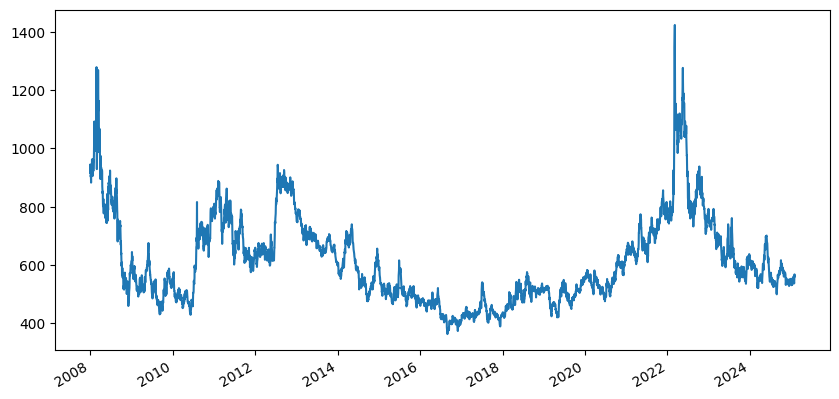

In [10]:
df_all['Price'].plot(figsize=(10, 5))

### 80/20 train-test split (no shuffling)

In [11]:
test_size = int(X.shape[0] * 0.2)

X_train = X[:-test_size]
y_train = y[:-test_size]

X_test = X[-test_size:]
y_test = y[-test_size:]

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (3567, 30, 32) (3567,)
Test set: (891, 30, 32) (891,)


### Chronological train-test split visualization

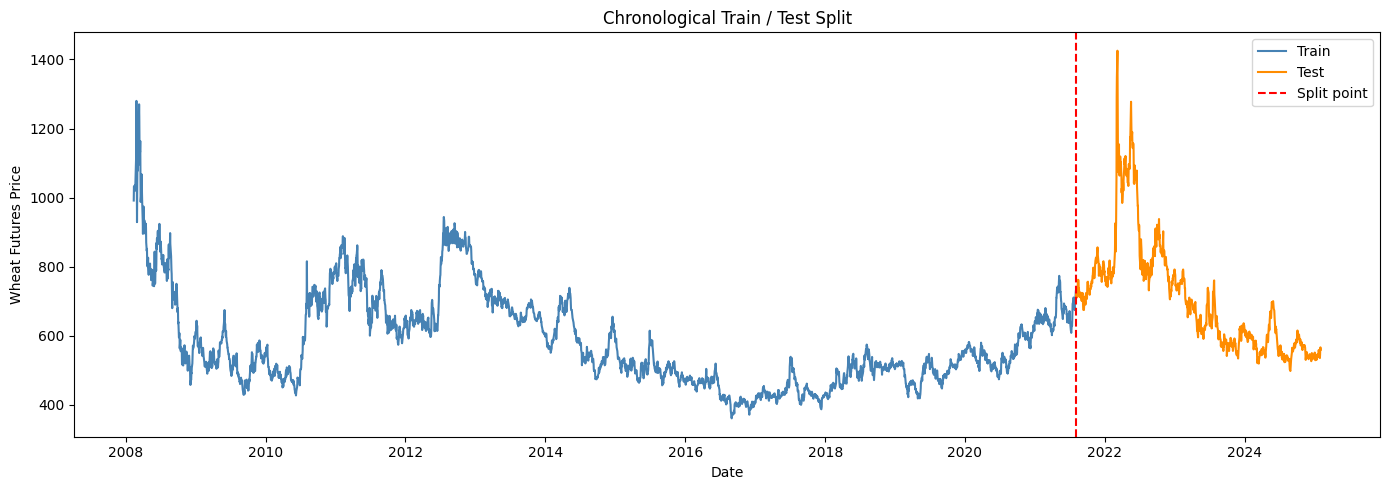

In [12]:
target_dates = df_all.index[lookback:]
train_dates = target_dates[:len(y_train)]
test_dates  = target_dates[len(y_train):]

plt.figure(figsize=(14, 5))
plt.plot(train_dates, y_train, label='Train', color='steelblue')
plt.plot(test_dates, y_test, label='Test', color='darkorange')
plt.axvline(x=train_dates[-1], color='red', linestyle='--', linewidth=1.5, label='Split point')
plt.title('Chronological Train / Test Split')
plt.xlabel('Date')
plt.ylabel('Wheat Futures Price')
plt.legend()
plt.tight_layout()
plt.show()

## BiRNN with Attention (no skip residual layer) (implements BaseForecastModel)

Architecture:
- **Stacked BiRNN layers**: each layer is a `Bidirectional(SimpleRNN)` and passes its sequence output to the next BiRNN layer
- **No residual skip or LayerNormalization block** in this variant
- **Self-Attention**: `SeqSelfAttention` learns to weight different timesteps in the lookback window
- **Global average pooling**: collapses the attended sequence into a single vector
- **Dense head**: produces the scalar price prediction

```
Input (B, T, F)
  -> BiRNN layer 1
  -> BiRNN layer 2
  -> ...
  -> SeqSelfAttention
  -> GlobalAveragePooling1D
  -> Dropout
  -> Dense(1) -> scalar prediction
```

The `fit()` method trains the final model on full `X_train` and stores the scalers. `predict()` reuses those exact scalers — no separate scaler is ever created for the test set.

In [13]:
class BiRNNAttentionModel(BaseForecastModel):
    """
    Bidirectional SimpleRNN with attention (no residual/skip connections)
    for one-step-ahead wheat futures price forecasting.
    """

    def __init__(
        self,
        task_type: str = 'regression',
        hidden_size: int = 64,
        num_layers: int = 2,
        weight_decay: float = 0.02,
        dropout: float = 0.2,
        early_stop_patience: int = 10,
        epochs: int = 100,
        batch_size: int = 64,
        learning_rate: float = 1e-3,
    ):
        super().__init__(
            task_type=task_type,
            hidden_size=hidden_size,
            num_layers=num_layers,
            weight_decay=weight_decay,
            dropout=dropout,
            early_stop_patience=early_stop_patience,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
        )

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.weight_decay = weight_decay
        self.dropout = dropout
        self.early_stop_patience = early_stop_patience
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate

        self.model = None
        self.x_scaler = None
        self.y_scaler = None
        self.lookback = None
        self.n_features = None

        # Stored after fit() for CV Best Fold plotting
        self._cv_val_actual = None
        self._cv_val_pred = None

    def _build_model(self, seq_length: int, feature_dim: int) -> Model:
        inputs = Input(shape=(seq_length, feature_dim))

        # First BiRNN block
        h = layers.Bidirectional(
            layers.SimpleRNN(
                units=self.hidden_size,
                dropout=self.dropout,
                kernel_regularizer=regularizers.l2(self.weight_decay),
                return_sequences=True,
            )
        )(inputs)

        # Additional BiRNN blocks (no residual add)
        for _ in range(self.num_layers - 1):
            h = layers.Bidirectional(
                layers.SimpleRNN(
                    units=self.hidden_size,
                    dropout=self.dropout,
                    kernel_regularizer=regularizers.l2(self.weight_decay),
                    return_sequences=True,
                )
            )(h)

        # Attention layer
        h = SeqSelfAttention(attention_activation='sigmoid')(h)

        x = layers.GlobalAveragePooling1D()(h)
        x = layers.Dropout(self.dropout)(x)

        outputs = layers.Dense(
            units=1,
            activation='linear',
            kernel_regularizer=regularizers.l2(self.weight_decay),
        )(x)

        return Model(inputs=inputs, outputs=outputs)

    # flatten -> scale -> reshape back to 3-D.
    def _scale_X(self, X, fit: bool = False):
        n, lb, nf = X.shape
        X_flat = X.reshape(n, lb * nf)
        if fit:
            self.x_scaler = StandardScaler()
            X_flat = self.x_scaler.fit_transform(X_flat)
        else:
            X_flat = self.x_scaler.transform(X_flat)
        return X_flat.reshape(n, lb, nf)

    def fit(self, X_train, y_train):
        """
        Train final model on full X_train.

        Scalers are fitted on all training samples and reused by predict(),
        so there is no train/test scaler mismatch.

        For plotting compatibility, a tail-window diagnostic prediction
        (last 20% of X_train) is stored in _cv_val_actual / _cv_val_pred.
        """
        self.lookback = X_train.shape[1]
        self.n_features = X_train.shape[2]

        X_train_s = self._scale_X(X_train, fit=True)

        self.y_scaler = StandardScaler()
        y_train_s = self.y_scaler.fit_transform(y_train.reshape(-1, 1))

        self.model = self._build_model(self.lookback, self.n_features)
        self.model.compile(
            optimizer=Adam(learning_rate=self.learning_rate),
            loss='mean_squared_error',
        )

        callbacks = [
            EarlyStopping(
                monitor='loss',
                patience=self.early_stop_patience,
                restore_best_weights=True,
                verbose=0,
            ),
            ReduceLROnPlateau(
                monitor='loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=0,
            ),
        ]

        self.model.fit(
            X_train_s, y_train_s,
            epochs=self.epochs,
            batch_size=self.batch_size,
            shuffle=False,
            callbacks=callbacks,
            verbose=0,
        )

        y_train_pred = self.y_scaler.inverse_transform(
            self.model.predict(X_train_s, verbose=0).reshape(-1, 1)
        ).ravel()

        print("=== Train set performance (full X_train) ===")
        print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.6f}")
        print(f"  MAE : {mean_absolute_error(y_train, y_train_pred):.6f}")
        print(f"  R_SQUARED  : {r2_score(y_train, y_train_pred):.6f}")

        tail_n = max(1, int(len(X_train) * 0.2))
        X_tail = X_train[-tail_n:]
        y_tail = y_train[-tail_n:]
        X_tail_s = self._scale_X(X_tail, fit=False)
        y_tail_pred = self.y_scaler.inverse_transform(
            self.model.predict(X_tail_s, verbose=0).reshape(-1, 1)
        ).ravel()

        self._cv_val_actual = y_tail
        self._cv_val_pred = y_tail_pred

        print("=== Tail diagnostic performance (last 20% of X_train) ===")
        print(f"  RMSE: {np.sqrt(mean_squared_error(y_tail, y_tail_pred)):.6f}")
        print(f"  MAE : {mean_absolute_error(y_tail, y_tail_pred):.6f}")
        print(f"  R_SQUARED  : {r2_score(y_tail, y_tail_pred):.6f}")

    def predict(self, X):
        if self.model is None:
            raise ValueError("Model not trained - call fit() first.")
        X_s = self._scale_X(X, fit=False)
        y_pred_s = self.model.predict(X_s, verbose=0)
        return self.y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()

    def evaluate(self, X_test, y_test):
        preds = self.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        return {'rmse': rmse, 'mae': mae, 'r2': r2}

    def save(self, filepath: str):
        self.model.save_weights(filepath + '.weights.h5')
        meta = {
            'hyperparameters': self.hyperparameters,
            'x_scaler': self.x_scaler,
            'y_scaler': self.y_scaler,
            'lookback': self.lookback,
            'n_features': self.n_features,
            'hidden_size': self.hidden_size,
            'num_layers': self.num_layers,
        }
        with open(filepath + '.meta.pkl', 'wb') as f:
            pickle.dump(meta, f)
        print(f"Model saved to {filepath}.*")

    def load(self, filepath: str):
        with open(filepath + '.meta.pkl', 'rb') as f:
            meta = pickle.load(f)
        self.x_scaler = meta['x_scaler']
        self.y_scaler = meta['y_scaler']
        self.lookback = meta['lookback']
        self.n_features = meta['n_features']
        self.hidden_size = meta['hidden_size']
        self.num_layers = meta['num_layers']
        self.model = self._build_model(self.lookback, self.n_features)
        self.model.load_weights(filepath + '.weights.h5')
        print(f"Model loaded from {filepath}.*")



### Cross-validation function

Runs 5-fold expanding-window CV and returns a metrics dict with average RMSE, MAE, R² and val_loss across folds.

In [14]:
def cv_birnn_attention(X_train, y_train, **kwargs):
    """Run 5-fold expanding-window CV; return dict of averaged metrics."""
    tscv = TimeSeriesSplit(n_splits=5)
    lookback, n_features = X_train.shape[1], X_train.shape[2]
    fold_metrics = {'val_loss': [], 'rmse': [], 'mae': [], 'r2': []}

    for fold, (train_idx, val_idx) in tqdm(enumerate(tscv.split(X_train)), total=5):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        ns_tr, ns_val = X_tr.shape[0], X_val.shape[0]
        X_tr_flat = X_tr.reshape((ns_tr, lookback * n_features))
        X_val_flat = X_val.reshape((ns_val, lookback * n_features))

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr_flat).reshape((ns_tr, lookback, n_features))
        X_val_s = scaler.transform(X_val_flat).reshape((ns_val, lookback, n_features))

        y_scaler = StandardScaler()
        y_tr_s = y_scaler.fit_transform(y_tr.reshape(-1, 1))
        y_val_s = y_scaler.transform(y_val.reshape(-1, 1))

        tmp = BiRNNAttentionModel(**kwargs)
        model = tmp._build_model(lookback, n_features)
        model.compile(
            optimizer=Adam(learning_rate=kwargs.get('learning_rate', 1e-3)),
            loss='mean_squared_error',
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=kwargs.get('early_stop_patience', 10),
            verbose=0,
            restore_best_weights=True,
        )
        #reduce learning rate when val_loss stops improving
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0,
        )

        history = model.fit(
            X_tr_s, y_tr_s,
            validation_data=(X_val_s, y_val_s),
            epochs=kwargs.get('epochs', 100),
            batch_size=kwargs.get('batch_size', 64),
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            verbose=0,
        )
        fold_metrics['val_loss'].append(min(history.history['val_loss']))

        y_val_pred = y_scaler.inverse_transform(
            model.predict(X_val_s, verbose=0).reshape(-1, 1)
        ).ravel()
        fold_metrics['rmse'].append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
        fold_metrics['mae'].append(mean_absolute_error(y_val, y_val_pred))
        fold_metrics['r2'].append(r2_score(y_val, y_val_pred))

    return {k: np.mean(v) for k, v in fold_metrics.items()}

## Default Hyperparameters — Training and Evaluation

Train the BiRNN + Attention model with **default** hyperparameters (hidden_size=64, num_layers=2, weight_decay=0.02, dropout=0.2, epochs=100, batch_size=64, lr=1e-3). Run full 5-fold CV for metrics, then train the final model on the last fold.

In [ ]:
# 5-fold CV with default hyperparameters
default_cv_metrics = cv_birnn_attention(X_train, y_train)

print("=== Default CV Metrics (avg across 5 folds) ===")
for k, v in default_cv_metrics.items():
    print(f"  {k.upper():<10}: {v:.6f}")

  0%|          | 0/5 [00:00<?, ?it/s]

=== Default CV Metrics (avg across 5 folds) ===
  VAL_LOSS  : 0.545849
  RMSE      : 58.444682
  MAE       : 48.529130
  R2        : 0.288105


In [ ]:

# Train final model with default hyperparameters
default_model = BiRNNAttentionModel()
default_model.fit(X_train, y_train)

default_test_metrics = default_model.evaluate(X_test, y_test)
print('\n=== Default — Test set performance ===')
for k, v in default_test_metrics.items():
    print(f'  {k.upper():<10}: {v:.6f}')

=== Train set performance (full X_train) ===
  RMSE: 35.251437
  MAE : 26.547569
  R_SQUARED  : 0.931921
=== Tail diagnostic performance (last 20% of X_train) ===
  RMSE: 21.783377
  MAE : 16.899753
  R_SQUARED  : 0.908536

=== Default — Test set performance ===
  RMSE      : 103.279869
  MAE       : 80.695481
  R2        : 0.594512


### Default — Tail Diagnostic, Train & Test plots

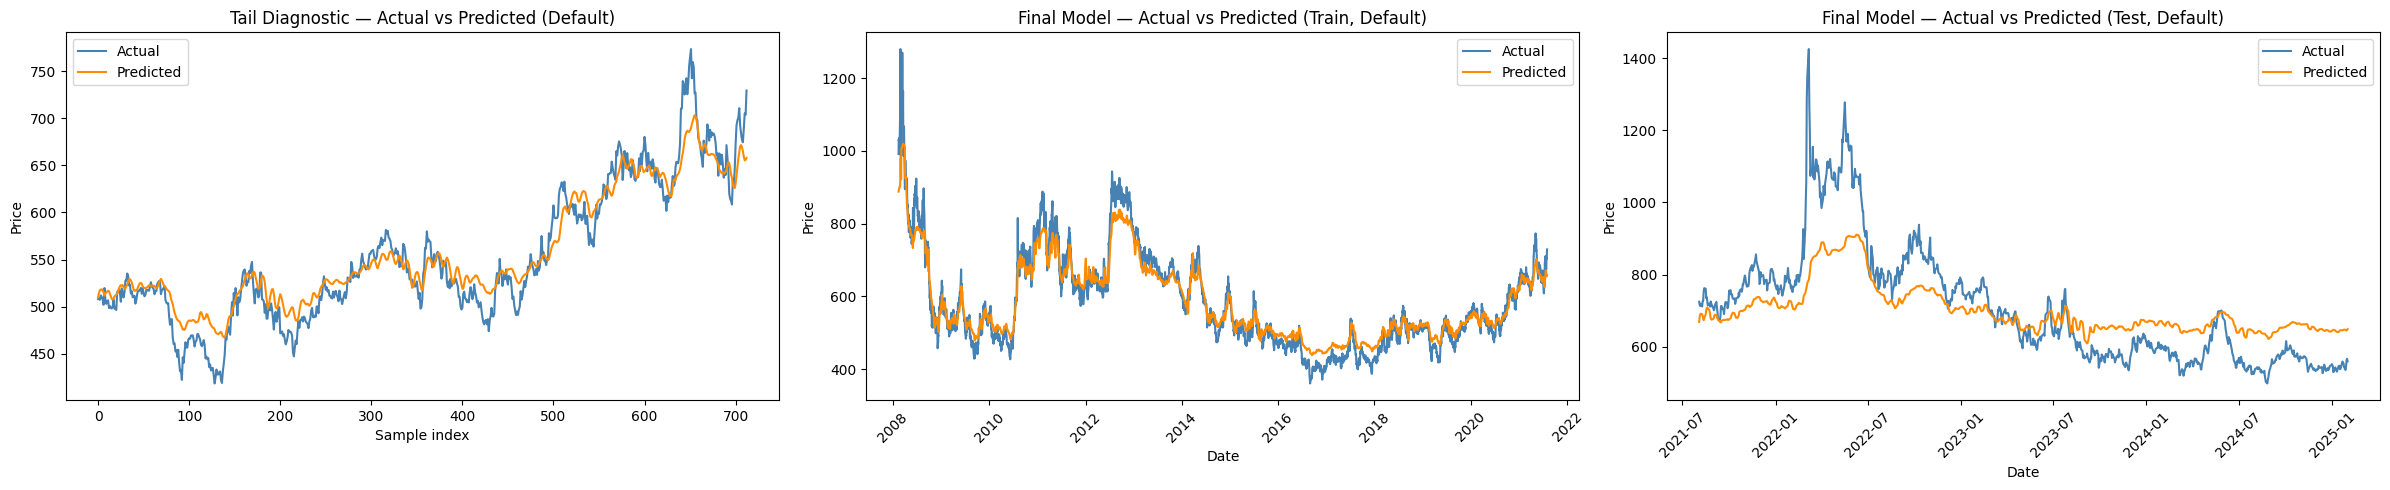

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 5))

# Tail diagnostic predictions
axes[0].plot(default_model._cv_val_actual, label='Actual', color='steelblue')
axes[0].plot(default_model._cv_val_pred, label='Predicted', color='darkorange')
axes[0].set_title('Tail Diagnostic — Actual vs Predicted (Default)')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Price')
axes[0].legend()

# Train predictions
train_dates = df_all.index[lookback:lookback + len(y_train)]
default_train_preds = default_model.predict(X_train)

axes[1].plot(train_dates, y_train, label='Actual', color='steelblue')
axes[1].plot(train_dates, default_train_preds, label='Predicted', color='darkorange')
axes[1].set_title('Final Model — Actual vs Predicted (Train, Default)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Test predictions
test_dates = df_all.index[-len(X_test):]
default_test_preds = default_model.predict(X_test)

axes[2].plot(test_dates, y_test, label='Actual', color='steelblue')
axes[2].plot(test_dates, default_test_preds, label='Predicted', color='darkorange')
axes[2].set_title('Final Model — Actual vs Predicted (Test, Default)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

## Optuna Hyperparameter Search (BiRNN + Attention)

Hyperparameters tuned: hidden_size, num_layers, weight_decay, dropout, early_stop_patience, epochs, batch_size, and learning_rate.

In [ ]:
def objective(trial):
    params = dict(
        hidden_size=trial.suggest_categorical('hidden_size', [32, 64, 128]),
        num_layers=trial.suggest_categorical('num_layers', [1, 2, 3]),
        weight_decay=trial.suggest_float('weight_decay', 5e-4, 2e-2, log=True),
        dropout=trial.suggest_float('dropout', 0.1, 0.3),
        early_stop_patience=trial.suggest_int('early_stop_patience', 10, 15),
        epochs=trial.suggest_int('epochs', 50, 200),
        batch_size=trial.suggest_categorical('batch_size', [32, 64]),
        learning_rate=trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True),
    )
    result = cv_birnn_attention(X_train, y_train, **params)
    trial.set_user_attr('cv_metrics', result)
    return result['val_loss']


N_TRIALS = 25
study = optuna.create_study(direction='minimize')
progress_bar = tqdm(total=N_TRIALS, desc='Optuna trials')
study.optimize(objective, n_trials=N_TRIALS, callbacks=[lambda study, trial: progress_bar.update(1)])
progress_bar.close()

print('\nBest CV score (val_loss):', study.best_value)
print('Best hyperparameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

optuna_cv_metrics = study.best_trial.user_attrs['cv_metrics']
print('\n=== Optuna CV Metrics (avg across 5 folds) ===')
for k, v in optuna_cv_metrics.items():
    print(f'  {k.upper():<10}: {v:.6f}')

[I 2026-02-22 13:52:49,853] A new study created in memory with name: no-name-c3b7e33c-3111-4956-80de-50a457673aa7


Optuna trials:   0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-02-22 13:55:20,319] Trial 0 finished with value: 0.7178212344646454 and parameters: {'hidden_size': 64, 'num_layers': 1, 'weight_decay': 0.004773775087921569, 'dropout': 0.13755060075224584, 'early_stop_patience': 12, 'epochs': 131, 'batch_size': 32, 'learning_rate': 0.0003017107772106665}. Best is trial 0 with value: 0.7178212344646454.


  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-02-22 14:57:36,931] Trial 23 finished with value: 0.23685374855995178 and parameters: {'hidden_size': 128, 'num_layers': 1, 'weight_decay': 0.0006960019540528043, 'dropout': 0.14873084010496773, 'early_stop_patience': 14, 'epochs': 51, 'batch_size': 64, 'learning_rate': 0.0007498531369488389}. Best is trial 1 with value: 0.21085498332977295.


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-02-22 14:59:26,706] Trial 24 finished with value: 0.19806584268808364 and parameters: {'hidden_size': 128, 'num_layers': 1, 'weight_decay': 0.0005017752361510938, 'dropout': 0.14709605693443337, 'early_stop_patience': 14, 'epochs': 51, 'batch_size': 64, 'learning_rate': 0.0006959990978522112}. Best is trial 24 with value: 0.19806584268808364.



Best CV score (val_loss): 0.19806584268808364
Best hyperparameters:
  hidden_size: 128
  num_layers: 1
  weight_decay: 0.0005017752361510938
  dropout: 0.14709605693443337
  early_stop_patience: 14
  epochs: 51
  batch_size: 64
  learning_rate: 0.0006959990978522112

=== Optuna CV Metrics (avg across 5 folds) ===
  VAL_LOSS  : 0.198066
  RMSE      : 51.755600
  MAE       : 41.892706
  R2        : 0.491371


## Train, Evaluate & Plot (BiRNN + Attention with Optuna best hyperparameters)

In [ ]:
best_params = study.best_params

optuna_model = BiRNNAttentionModel(
    task_type='regression',
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    weight_decay=best_params['weight_decay'],
    dropout=best_params['dropout'],
    early_stop_patience=best_params['early_stop_patience'],
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    learning_rate=best_params['learning_rate'],
)

optuna_model.fit(X_train, y_train)

optuna_test_metrics = optuna_model.evaluate(X_test, y_test)
print('\n=== Optuna — Test set performance ===')
for k, v in optuna_test_metrics.items():
    print(f'  {k.upper():<10}: {v:.6f}')

=== Train set performance (full X_train) ===
  RMSE: 34.897645
  MAE : 25.385116
  R_SQUARED  : 0.933280
=== Tail diagnostic performance (last 20% of X_train) ===
  RMSE: 27.600321
  MAE : 20.530936
  R_SQUARED  : 0.853165

=== Optuna — Test set performance ===
  RMSE      : 74.731993
  MAE       : 55.348699
  R2        : 0.787695


### Optuna — Tail Diagnostic, Train & Test plots

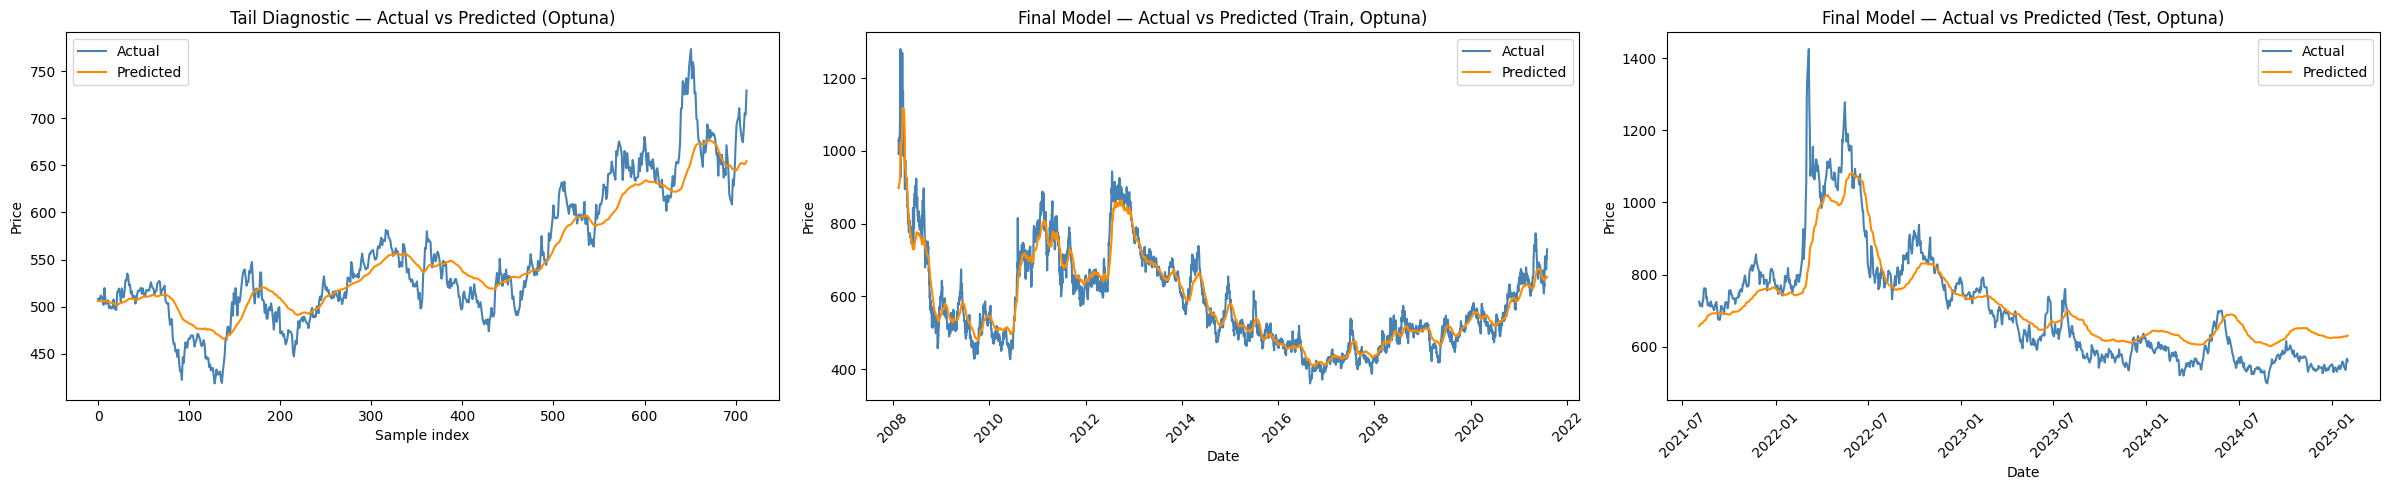

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 5))

# Tail diagnostic predictions
axes[0].plot(optuna_model._cv_val_actual, label='Actual', color='steelblue')
axes[0].plot(optuna_model._cv_val_pred, label='Predicted', color='darkorange')
axes[0].set_title('Tail Diagnostic — Actual vs Predicted (Optuna)')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Price')
axes[0].legend()

# Train predictions
train_dates = df_all.index[lookback:lookback + len(y_train)]
optuna_train_preds = optuna_model.predict(X_train)

axes[1].plot(train_dates, y_train, label='Actual', color='steelblue')
axes[1].plot(train_dates, optuna_train_preds, label='Predicted', color='darkorange')
axes[1].set_title('Final Model — Actual vs Predicted (Train, Optuna)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Test predictions
test_dates = df_all.index[-len(X_test):]
optuna_test_preds = optuna_model.predict(X_test)

axes[2].plot(test_dates, y_test, label='Actual', color='steelblue')
axes[2].plot(test_dates, optuna_test_preds, label='Predicted', color='darkorange')
axes[2].set_title('Final Model — Actual vs Predicted (Test, Optuna)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

## Naive Baseline

Each day's price prediction equals the previous day's price.

In [ ]:
last_train_price = y_train[-1]
naive_preds = np.empty(len(y_test))
naive_preds[0] = last_train_price
naive_preds[1:] = y_test[:-1]

naive_rmse = np.sqrt(mean_squared_error(y_test, naive_preds))
naive_mae = mean_absolute_error(y_test, naive_preds)
naive_r2 = r2_score(y_test, naive_preds)

print('=== Naive One-Day-Ahead Forecast ===')
print(f'RMSE: {naive_rmse:.6f}')
print(f'R_SQUARED  : {naive_r2:.6f}')
print(f'MAE : {naive_mae:.6f}')

=== Naive One-Day-Ahead Forecast ===
RMSE: 20.370589
R_SQUARED  : 0.984226
MAE : 12.850842


## Model Comparison

In [ ]:
comparison = pd.DataFrame([
    {
        'Model': 'Naive',
        'RMSE': naive_rmse,
        'MAE': naive_mae,
        'R_SQUARED': naive_r2,
    },
    {
        'Model': 'BiRNN + Attn (Default CV)',
        'RMSE': default_cv_metrics['rmse'],
        'MAE': default_cv_metrics['mae'],
        'R_SQUARED': default_cv_metrics['r2'],
    },
    {
        'Model': 'BiRNN + Attn (Default Final)',
        'RMSE': default_test_metrics['rmse'],
        'MAE': default_test_metrics['mae'],
        'R_SQUARED': default_test_metrics['r2'],
    },
    {
        'Model': 'BiRNN + Attn (Optuna CV)',
        'RMSE': optuna_cv_metrics['rmse'],
        'MAE': optuna_cv_metrics['mae'],
        'R_SQUARED': optuna_cv_metrics['r2'],
    },
    {
        'Model': 'BiRNN + Attn (Optuna Final)',
        'RMSE': optuna_test_metrics['rmse'],
        'MAE': optuna_test_metrics['mae'],
        'R_SQUARED': optuna_test_metrics['r2'],
    },
])

comparison = comparison.set_index('Model')

comparison.style \
    .highlight_min(subset=['RMSE', 'MAE'], color='#d4edda') \
    .highlight_max(subset=['R_SQUARED'], color='#d4edda') \
    .format('{:.6f}')

,RMSE,MAE,R_SQUARED
Model,,,
Naive,20.370589,12.850842,0.984226
BiRNN + Attn (Default CV),58.444682,48.529130,0.288105
BiRNN + Attn (Default Final),103.279869,80.695481,0.594512
BiRNN + Attn (Optuna CV),51.755600,41.892706,0.491371
BiRNN + Attn (Optuna Final),74.731993,55.348699,0.787695


## Save & Load

In [ ]:
optuna_model.save('birnn_attention_wheat')

loaded = BiRNNAttentionModel()
loaded.load('birnn_attention_wheat')

loaded_metrics = loaded.evaluate(X_test, y_test)
print('\nLoaded model test metrics:')
for name, value in loaded_metrics.items():
    print(f'  {name.upper()}: {value:.6f}')

print(f"\nPredictions match: {np.allclose(optuna_model.predict(X_test), loaded.predict(X_test))}")

Model saved to birnn_attention_wheat.*
Model loaded from birnn_attention_wheat.*

Loaded model test metrics:
  RMSE: 74.731993
  MAE: 55.348699
  R2: 0.787695

Predictions match: True


# Part 2: Next-Day Binary Classification

This section adapts the BiRNN + Attention architecture for **binary classification** —
predicting whether the wheat futures price will move **up (+1)** or **down (0)** on the
next trading day.

**Pipeline (per assignment specification):**

1. Load raw FRED-MD vintage and apply **t-code stationarity transformations** to each
   of the 31 macro variables.
2. Account for the **one-month reporting delay** (shift macro dates forward by one month).
3. **Forward-fill** monthly macro data to daily frequency.
4. Input features: **30 lagged daily closing prices** (t−1 … t−30) +
   **31 t-code-transformed macro variables**. No additional indicators.
5. Target: next-day price direction (binary).
6. **StandardScaler fit on training data only** per CV fold (no data leakage).
7. **5-fold expanding-window time-series cross-validation** (TimeSeriesSplit).
8. Evaluation: Accuracy, Precision, Recall, Confusion Matrix, F1-score, ROC-AUC.

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

print("Classification imports loaded.")

## Load raw FRED-MD and apply t-code stationarity transformations

Each FRED-MD variable has a transformation code (t-code) indicating how to make it
stationary. The codes are read directly from the second row of the vintage CSV.

| T-Code | Transformation | Formula |
|--------|----------------|---------|
| 1 | Level (no change) | $x_t$ |
| 2 | First difference | $x_t - x_{t-1}$ |
| 3 | Second difference | $(x_t - x_{t-1}) - (x_{t-1} - x_{t-2})$ |
| 4 | Log | $\ln(x_t)$ |
| 5 | Log first difference | $\ln(x_t) - \ln(x_{t-1})$ |
| 6 | Log second difference | $(\ln x_t - \ln x_{t-1}) - (\ln x_{t-1} - \ln x_{t-2})$ |

In [ ]:
fred_md_path = '/content/drive/MyDrive/Quants /FredMD_Dataset/2025-10-MD.csv'

tcodes_row = pd.read_csv(fred_md_path, nrows=1)
fred_raw = pd.read_csv(fred_md_path, skiprows=[1])
fred_raw['sasdate'] = pd.to_datetime(fred_raw['sasdate'], format='%m/%d/%Y')
fred_raw = fred_raw.set_index('sasdate').sort_index()

features_31 = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE",
    "USTRADE", "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio",
    "FEDFUNDS", "TB3MS", "TB6MS", "GS1", "GS5", "GS10",
    "AAA", "BAA", "TB3SMFFM", "TB6SMFFM", "T1YFFM",
    "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM",
    "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "PPICMM", "UMCSENTx",
]

tcode_map = {}
for col in features_31:
    tcode_map[col] = int(float(tcodes_row[col].values[0]))

print("T-codes for the 31 required variables:")
for col, tc in tcode_map.items():
    print(f"  {col:20s} -> t-code {tc}")

In [ ]:
def apply_tcode(series, tcode):
    if tcode == 1:
        return series
    elif tcode == 2:
        return series.diff()
    elif tcode == 3:
        return series.diff().diff()
    elif tcode == 4:
        return np.log(series.clip(lower=1e-10))
    elif tcode == 5:
        return np.log(series.clip(lower=1e-10)).diff()
    elif tcode == 6:
        return np.log(series.clip(lower=1e-10)).diff().diff()
    elif tcode == 7:
        return (series / series.shift(1) - 1).diff()
    else:
        return series

fred_selected = fred_raw[features_31].copy()
fred_selected = fred_selected.apply(pd.to_numeric, errors='coerce')

for col in features_31:
    fred_selected[col] = apply_tcode(fred_selected[col], tcode_map[col])

fred_transformed = fred_selected.dropna()
fred_transformed = fred_transformed.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Raw FRED-MD shape:            {fred_raw[features_31].shape}")
print(f"After t-code transformation:  {fred_transformed.shape}")
print(f"Date range: {fred_transformed.index.min().date()} to {fred_transformed.index.max().date()}")
fred_transformed.head()

### Apply one-month reporting delay and forward-fill to daily

FRED-MD data is released with a one-month lag: on any given day in month $m$, only
data through month $m-1$ is available. We shift the macro dates forward by one month,
then forward-fill to create a daily series aligned with the price data.

In [ ]:
df_macro_cls = fred_transformed.copy()
df_macro_cls.index = df_macro_cls.index + pd.DateOffset(months=1)

start = df_macro_cls.index.min()
end = df_macro_cls.index.max() + pd.offsets.MonthEnd(0)
all_days = pd.date_range(start, end, freq='D')
df_macro_cls = df_macro_cls.reindex(all_days).ffill()

print(f"Daily macro features shape: {df_macro_cls.shape}")
print(f"Date range: {df_macro_cls.index.min().date()} to {df_macro_cls.index.max().date()}")
df_macro_cls.head()

### Merge with daily wheat prices and construct classification dataset

Features at each time step: **daily closing price + 31 t-code-transformed macro
variables** = 32 features.

- **Rolling window**: 30-day lookback (t−30 to t−1).
- **Target**: price direction on day t — **1** if price went up, **0** if down.

In [ ]:
df_cls = df_macro_cls.join(df_price, how='inner')
df_cls = df_cls['2008-01-01':]

cols_order = [c for c in df_cls.columns if c != 'Price'] + ['Price']
df_cls = df_cls[cols_order]

print(f"Classification dataset: {df_cls.shape}")
print(f"Date range: {df_cls.index.min().date()} to {df_cls.index.max().date()}")
print(f"Columns ({df_cls.shape[1]}): {list(df_cls.columns)}")
df_cls.head()

In [ ]:
lookback_cls = 30
price_col_idx = df_cls.columns.get_loc('Price')
data_cls = df_cls.values

X_cls, y_cls = [], []
for i in range(lookback_cls, len(data_cls)):
    X_cls.append(data_cls[i - lookback_cls : i])
    y_cls.append(1 if data_cls[i, price_col_idx] > data_cls[i - 1, price_col_idx] else 0)

X_cls = np.array(X_cls)
y_cls = np.array(y_cls)

print(f"X_cls shape: {X_cls.shape}  (samples, lookback, features)")
print(f"y_cls shape: {y_cls.shape}")
print(f"Class distribution: Up={y_cls.sum()} ({y_cls.mean():.2%}), "
      f"Down={len(y_cls)-y_cls.sum()} ({1-y_cls.mean():.2%})")

### Chronological train / test split

Time-based split (80 % train, 20 % test). No shuffling — the test set is strictly
in the future relative to training data.

In [ ]:
split_cls = int(len(X_cls) * 0.8)
X_train_cls = X_cls[:split_cls]
y_train_cls = y_cls[:split_cls]
X_test_cls  = X_cls[split_cls:]
y_test_cls  = y_cls[split_cls:]

target_dates_cls = df_cls.index[lookback_cls:]
train_dates_cls  = target_dates_cls[:split_cls]
test_dates_cls   = target_dates_cls[split_cls:]

print(f"Train: {X_train_cls.shape[0]} samples "
      f"({train_dates_cls[0].date()} to {train_dates_cls[-1].date()})")
print(f"Test:  {X_test_cls.shape[0]} samples "
      f"({test_dates_cls[0].date()} to {test_dates_cls[-1].date()})")
print(f"\nTrain class dist: Up={y_train_cls.sum()} ({y_train_cls.mean():.2%}), "
      f"Down={len(y_train_cls)-y_train_cls.sum()} ({1-y_train_cls.mean():.2%})")
print(f"Test  class dist: Up={y_test_cls.sum()} ({y_test_cls.mean():.2%}), "
      f"Down={len(y_test_cls)-y_test_cls.sum()} ({1-y_test_cls.mean():.2%})")

## BiRNN + Attention binary classifier

Same bidirectional SimpleRNN + self-attention architecture as Part 1, adapted for
binary classification:

- Output activation: **sigmoid** (probability of "up").
- Loss function: **binary cross-entropy**.
- **Class weights** computed from training data to handle any imbalance.

In [ ]:
class BiRNNAttentionClassifier(BaseForecastModel):
    """
    Bidirectional SimpleRNN with self-attention for binary classification
    of next-day wheat futures price direction.
    """

    def __init__(
        self,
        task_type: str = 'classification',
        hidden_size: int = 64,
        num_layers: int = 2,
        weight_decay: float = 0.02,
        dropout: float = 0.2,
        early_stop_patience: int = 10,
        epochs: int = 100,
        batch_size: int = 64,
        learning_rate: float = 1e-3,
    ):
        super().__init__(
            task_type=task_type,
            hidden_size=hidden_size,
            num_layers=num_layers,
            weight_decay=weight_decay,
            dropout=dropout,
            early_stop_patience=early_stop_patience,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
        )
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.weight_decay = weight_decay
        self.dropout = dropout
        self.early_stop_patience = early_stop_patience
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate

        self.model = None
        self.x_scaler = None
        self.lookback = None
        self.n_features = None

    def _build_model(self, seq_length: int, feature_dim: int) -> Model:
        inputs = Input(shape=(seq_length, feature_dim))

        h = layers.Bidirectional(
            layers.SimpleRNN(
                units=self.hidden_size,
                dropout=self.dropout,
                kernel_regularizer=regularizers.l2(self.weight_decay),
                return_sequences=True,
            )
        )(inputs)

        for _ in range(self.num_layers - 1):
            h = layers.Bidirectional(
                layers.SimpleRNN(
                    units=self.hidden_size,
                    dropout=self.dropout,
                    kernel_regularizer=regularizers.l2(self.weight_decay),
                    return_sequences=True,
                )
            )(h)

        h = SeqSelfAttention(attention_activation='sigmoid')(h)
        x = layers.GlobalAveragePooling1D()(h)
        x = layers.Dropout(self.dropout)(x)

        outputs = layers.Dense(
            units=1,
            activation='sigmoid',
            kernel_regularizer=regularizers.l2(self.weight_decay),
        )(x)

        return Model(inputs=inputs, outputs=outputs)

    def _scale_X(self, X, fit: bool = False):
        n, lb, nf = X.shape
        X_flat = X.reshape(n, lb * nf)
        if fit:
            self.x_scaler = StandardScaler()
            X_flat = self.x_scaler.fit_transform(X_flat)
        else:
            X_flat = self.x_scaler.transform(X_flat)
        return X_flat.reshape(n, lb, nf)

    def fit(self, X_train, y_train):
        self.lookback   = X_train.shape[1]
        self.n_features = X_train.shape[2]
        X_train_s = self._scale_X(X_train, fit=True)

        cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
        class_weight = {0: cw[0], 1: cw[1]}

        self.model = self._build_model(self.lookback, self.n_features)
        self.model.compile(
            optimizer=Adam(learning_rate=self.learning_rate),
            loss='binary_crossentropy',
            metrics=['accuracy'],
        )

        callbacks = [
            EarlyStopping(
                monitor='loss', patience=self.early_stop_patience,
                restore_best_weights=True, verbose=0,
            ),
            ReduceLROnPlateau(
                monitor='loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0,
            ),
        ]

        self.model.fit(
            X_train_s, y_train,
            epochs=self.epochs,
            batch_size=self.batch_size,
            shuffle=False,
            callbacks=callbacks,
            class_weight=class_weight,
            verbose=0,
        )

        train_probs = self.model.predict(X_train_s, verbose=0).ravel()
        train_preds = (train_probs >= 0.5).astype(int)
        print("=== Train set performance (full X_train) ===")
        print(f"  Accuracy: {accuracy_score(y_train, train_preds):.6f}")
        print(f"  F1:       {f1_score(y_train, train_preds, zero_division=0):.6f}")

    def predict(self, X):
        if self.model is None:
            raise ValueError("Model not trained -- call fit() first.")
        X_s = self._scale_X(X, fit=False)
        return self.model.predict(X_s, verbose=0).ravel()

    def evaluate(self, X_test, y_test, threshold=0.5):
        probs = self.predict(X_test)
        preds = (probs >= threshold).astype(int)
        metrics = {
            'accuracy':  accuracy_score(y_test, preds),
            'precision': precision_score(y_test, preds, zero_division=0),
            'recall':    recall_score(y_test, preds, zero_division=0),
            'f1':        f1_score(y_test, preds, zero_division=0),
        }
        try:
            metrics['auc_roc'] = roc_auc_score(y_test, probs)
        except ValueError:
            metrics['auc_roc'] = 0.5
        return metrics

    def save(self, filepath: str):
        self.model.save_weights(filepath + '.weights.h5')
        meta = {
            'hyperparameters': self.hyperparameters,
            'x_scaler': self.x_scaler,
            'lookback': self.lookback,
            'n_features': self.n_features,
        }
        with open(filepath + '.meta_cls.pkl', 'wb') as f:
            pickle.dump(meta, f)

    def load(self, filepath: str):
        with open(filepath + '.meta_cls.pkl', 'rb') as f:
            meta = pickle.load(f)
        self.x_scaler   = meta['x_scaler']
        self.lookback    = meta['lookback']
        self.n_features  = meta['n_features']
        self.model = self._build_model(self.lookback, self.n_features)
        self.model.load_weights(filepath + '.weights.h5')

print("BiRNNAttentionClassifier defined.")

### 5-fold expanding-window cross-validation (classification)

For each fold:
1. **StandardScaler is fit on training data only** and applied to the validation fold.
2. **Class weights** are computed from the training fold to handle imbalance.
3. All classification metrics are recorded per fold and averaged.

In [ ]:
def cv_birnn_attention_cls(X_train, y_train, **kwargs):
    """5-fold expanding-window CV for classification; returns averaged metrics."""
    tscv = TimeSeriesSplit(n_splits=5)
    lookback_cv   = X_train.shape[1]
    n_features_cv = X_train.shape[2]

    fold_metrics = {
        'accuracy': [], 'precision': [], 'recall': [],
        'f1': [], 'auc_roc': [], 'val_loss': [],
    }
    all_val_probs, all_val_true = [], []

    for fold, (train_idx, val_idx) in tqdm(
        enumerate(tscv.split(X_train)), total=5, desc="CV Folds"
    ):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        ns_tr  = X_tr.shape[0]
        ns_val = X_val.shape[0]
        scaler = StandardScaler()
        X_tr_s  = scaler.fit_transform(
            X_tr.reshape(ns_tr, -1)
        ).reshape(ns_tr, lookback_cv, n_features_cv)
        X_val_s = scaler.transform(
            X_val.reshape(ns_val, -1)
        ).reshape(ns_val, lookback_cv, n_features_cv)

        cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr)
        class_weight = {0: cw[0], 1: cw[1]}

        tmp   = BiRNNAttentionClassifier(**kwargs)
        model = tmp._build_model(lookback_cv, n_features_cv)
        model.compile(
            optimizer=Adam(learning_rate=kwargs.get('learning_rate', 1e-3)),
            loss='binary_crossentropy',
            metrics=['accuracy'],
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=kwargs.get('early_stop_patience', 10),
            verbose=0, restore_best_weights=True,
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5,
            min_lr=1e-6, verbose=0,
        )

        history = model.fit(
            X_tr_s, y_tr,
            validation_data=(X_val_s, y_val),
            epochs=kwargs.get('epochs', 100),
            batch_size=kwargs.get('batch_size', 64),
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            class_weight=class_weight,
            verbose=0,
        )
        fold_metrics['val_loss'].append(min(history.history['val_loss']))

        val_probs = model.predict(X_val_s, verbose=0).ravel()
        val_preds = (val_probs >= 0.5).astype(int)

        fold_metrics['accuracy'].append(accuracy_score(y_val, val_preds))
        fold_metrics['precision'].append(
            precision_score(y_val, val_preds, zero_division=0))
        fold_metrics['recall'].append(
            recall_score(y_val, val_preds, zero_division=0))
        fold_metrics['f1'].append(
            f1_score(y_val, val_preds, zero_division=0))
        try:
            fold_metrics['auc_roc'].append(roc_auc_score(y_val, val_probs))
        except ValueError:
            fold_metrics['auc_roc'].append(0.5)

        all_val_probs.extend(val_probs)
        all_val_true.extend(y_val)

        print(f"  Fold {fold+1}: "
              f"Acc={fold_metrics['accuracy'][-1]:.4f}  "
              f"F1={fold_metrics['f1'][-1]:.4f}  "
              f"AUC={fold_metrics['auc_roc'][-1]:.4f}")

    avg_metrics = {k: np.mean(v) for k, v in fold_metrics.items()}
    return avg_metrics, np.array(all_val_true), np.array(all_val_probs)

## Default Hyperparameters — Training and Evaluation

Train the BiRNN + Attention classifier with **default** hyperparameters
(hidden_size=64, num_layers=2, dropout=0.2, lr=1e-3, epochs=100,
batch_size=64) and evaluate via 5-fold expanding-window cross-validation.

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

default_cls_metrics, default_val_true, default_val_probs = cv_birnn_attention_cls(
    X_train_cls, y_train_cls,
)

print("\n=== Default CV Classification Metrics (5-fold avg) ===")
for k, v in default_cls_metrics.items():
    print(f"  {k:12s}: {v:.6f}")

In [ ]:
default_val_preds = (default_val_probs >= 0.5).astype(int)

print("=== Default CV — Confusion Matrix (aggregated over all folds) ===")
print(confusion_matrix(default_val_true, default_val_preds))
print()
print(classification_report(
    default_val_true, default_val_preds, target_names=['Down', 'Up']))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
cm = confusion_matrix(default_val_true, default_val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Default CV — Confusion Matrix')
plt.tight_layout()
plt.show()

## Optuna Hyperparameter Tuning

Search over learning rate, hidden size, number of layers, weight decay, dropout,
early-stop patience, epochs, and batch size. The objective **maximises the average
F1-score** across 5-fold CV.

In [ ]:
def optuna_cls_objective(trial):
    params = {
        'learning_rate':      trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True),
        'hidden_size':        trial.suggest_categorical('hidden_size', [32, 64, 128]),
        'num_layers':         trial.suggest_int('num_layers', 1, 3),
        'weight_decay':       trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True),
        'dropout':            trial.suggest_float('dropout', 0.1, 0.5),
        'early_stop_patience': trial.suggest_int('early_stop_patience', 5, 15),
        'epochs':             trial.suggest_categorical('epochs', [50, 100, 150]),
        'batch_size':         trial.suggest_categorical('batch_size', [32, 64, 128]),
    }
    avg_metrics, _, _ = cv_birnn_attention_cls(X_train_cls, y_train_cls, **params)
    return avg_metrics['f1']

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_cls = optuna.create_study(direction='maximize', study_name='BiRNN_Attn_Cls')
study_cls.optimize(optuna_cls_objective, n_trials=25, show_progress_bar=True)

print(f"\nBest F1: {study_cls.best_value:.6f}")
print("Best hyperparameters:")
for k, v in study_cls.best_params.items():
    print(f"  {k}: {v}")

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

best_cls_params = study_cls.best_params

optuna_cls_metrics, optuna_val_true, optuna_val_probs = cv_birnn_attention_cls(
    X_train_cls, y_train_cls, **best_cls_params,
)

print("\n=== Optuna CV Classification Metrics (5-fold avg) ===")
for k, v in optuna_cls_metrics.items():
    print(f"  {k:12s}: {v:.6f}")

In [ ]:
optuna_val_preds = (optuna_val_probs >= 0.5).astype(int)

print("=== Optuna CV — Confusion Matrix (aggregated over all folds) ===")
print(confusion_matrix(optuna_val_true, optuna_val_preds))
print()
print(classification_report(
    optuna_val_true, optuna_val_preds, target_names=['Down', 'Up']))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
cm = confusion_matrix(optuna_val_true, optuna_val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Optuna CV — Confusion Matrix')
plt.tight_layout()
plt.show()

## Final Evaluation on Held-Out Test Set

Train the final classifier on the **entire training set** using the best Optuna
hyperparameters, then evaluate on the chronologically held-out test set.
The StandardScaler is fit on training data only.

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

final_cls = BiRNNAttentionClassifier(**best_cls_params)
final_cls.fit(X_train_cls, y_train_cls)

test_probs = final_cls.predict(X_test_cls)
test_preds = (test_probs >= 0.5).astype(int)

print("\n=== Final Test Set Results ===")
print(f"  Accuracy:  {accuracy_score(y_test_cls, test_preds):.6f}")
print(f"  Precision: {precision_score(y_test_cls, test_preds, zero_division=0):.6f}")
print(f"  Recall:    {recall_score(y_test_cls, test_preds, zero_division=0):.6f}")
print(f"  F1-score:  {f1_score(y_test_cls, test_preds, zero_division=0):.6f}")
try:
    print(f"  AUC-ROC:   {roc_auc_score(y_test_cls, test_probs):.6f}")
except ValueError:
    print("  AUC-ROC:   N/A")
print()
print(confusion_matrix(y_test_cls, test_preds))
print()
print(classification_report(
    y_test_cls, test_preds, target_names=['Down', 'Up']))

### Visualizations

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_test = confusion_matrix(y_test_cls, test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Test Set — Confusion Matrix')

try:
    fpr, tpr, _ = roc_curve(y_test_cls, test_probs)
    auc_val = roc_auc_score(y_test_cls, test_probs)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC (AUC = {auc_val:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--',
                 label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Test Set — ROC Curve')
    axes[1].legend(loc='lower right')
except ValueError:
    axes[1].text(0.5, 0.5, 'ROC unavailable', ha='center', va='center')

plt.tight_layout()
plt.show()

In [ ]:
rolling_correct = pd.Series(
    (test_preds == y_test_cls).astype(int),
    index=test_dates_cls,
)
rolling_acc = rolling_correct.rolling(window=50, min_periods=10).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_acc.index, rolling_acc.values, color='steelblue', lw=1.5)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7,
           label='Random baseline (50%)')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Accuracy (50-day)')
ax.set_title('Test Set — Rolling Classification Accuracy Over Time')
ax.legend()
plt.tight_layout()
plt.show()

## Classification — Model Comparison

In [ ]:
def _safe_auc(y_true, y_probs):
    try:
        return roc_auc_score(y_true, y_probs)
    except ValueError:
        return 0.5

cls_comparison = pd.DataFrame([
    {
        'Model': 'BiRNN + Attn (Default CV)',
        'Accuracy':  default_cls_metrics['accuracy'],
        'Precision': default_cls_metrics['precision'],
        'Recall':    default_cls_metrics['recall'],
        'F1':        default_cls_metrics['f1'],
        'AUC-ROC':   default_cls_metrics['auc_roc'],
    },
    {
        'Model': 'BiRNN + Attn (Optuna CV)',
        'Accuracy':  optuna_cls_metrics['accuracy'],
        'Precision': optuna_cls_metrics['precision'],
        'Recall':    optuna_cls_metrics['recall'],
        'F1':        optuna_cls_metrics['f1'],
        'AUC-ROC':   optuna_cls_metrics['auc_roc'],
    },
    {
        'Model': 'BiRNN + Attn (Final Test)',
        'Accuracy':  accuracy_score(y_test_cls, test_preds),
        'Precision': precision_score(y_test_cls, test_preds, zero_division=0),
        'Recall':    recall_score(y_test_cls, test_preds, zero_division=0),
        'F1':        f1_score(y_test_cls, test_preds, zero_division=0),
        'AUC-ROC':   _safe_auc(y_test_cls, test_probs),
    },
])

cls_comparison = cls_comparison.set_index('Model')
cls_comparison.style \
    .highlight_max(subset=['Accuracy', 'F1', 'AUC-ROC'], color='#d4edda') \
    .format('{:.6f}')